Question 1 :

An airline tracks flight delays (in minutes) for 20 flights. Analyze the flight delays to calculate percentiles, detect outliers, and evaluate the overall distribution.

Percentiles (10th, 25th, 50th, 75th, 90th): [ 14.5 28.75 52.5 82.5 123.0 ]
IQR: 53.75
Outliers: [200]


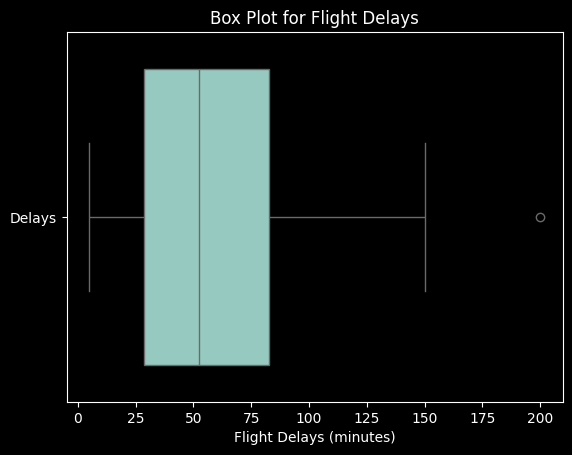

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

delays = [15, 30, 45, 20, 25, 100, 5, 60, 35, 50, 
          120, 80, 10, 75, 90, 200, 55, 40, 70, 150]
delays = pd.DataFrame(delays, columns=['Delays'])

Q10, Q25, Q50, Q75, Q90 = np.percentile(delays['Delays'], [10,25,50,75,90])

print('Percentiles (10th, 25th, 50th, 75th, 90th):', '[', Q10, Q25, Q50, Q75, Q90.round(0), ']')
IQR = Q75-Q25
print('IQR:', IQR)

lowbound = Q25-IQR*1.5
highbound = Q75+IQR*1.5

outliers = delays['Delays'][(delays['Delays'] < lowbound) | (delays['Delays'] > highbound)]
print("Outliers:", "No outliers detected." if outliers.empty else outliers.tolist())

sns.boxplot(delays, orient='h')
plt.xlabel('Flight Delays (minutes)')
plt.title('Box Plot for Flight Delays')
plt.show()


Question 2 :

A company wants to analyze the salary distribution of its employees to understand the central tendency and determine whether the data is skewed.

Mean Salary: 56950.0
Median Salary: 57500.0
Mode Salary: 30000
The data is Left Skewed (Negative Skew)


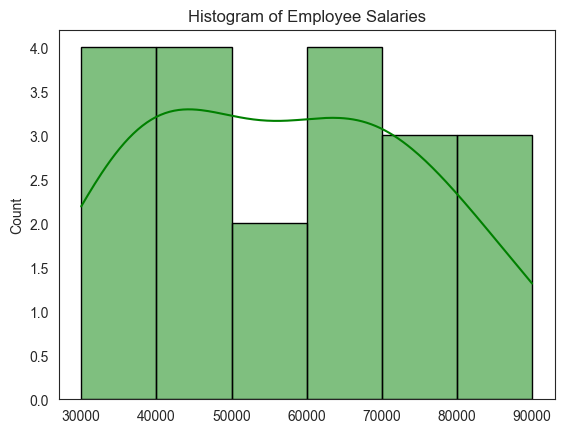

In [2]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

salaries = [30000, 32000, 35000, 37000, 40000, 42000, 45000, 47000, 50000, 55000,
            60000, 62000, 65000, 67000, 70000, 72000, 75000, 80000, 85000, 90000]

mean_sal = np.mean(salaries)
median_sal= np.median(salaries)
mode_sal = stats.mode(salaries)
print( 'Mean Salary:', mean_sal)
print( 'Median Salary:', median_sal)
print( 'Mode Salary:', mode_sal[0])

# Skewness Check
if mean_sal > median_sal:
    print("The data is Right Skewed (Positive Skew)")
elif mean_sal < median_sal:
    print("The data is Left Skewed (Negative Skew)")
else:
    print("The data is Symmetrical")

sns.set_style('white')
sns.histplot(salaries, bins=6, kde=True, color='g', edgecolor='black')
plt.ylabel('Count')
plt.title('Histogram of Employee Salaries')
plt.show()


Question 3:

 A school wants to analyze the exam performance of students across three subjects: Mathematics, Science, and English. How can Data Science concepts be applied to understand their performance?

Descriptive Statistics
       Mathematics    Science    English
count    10.000000  10.000000  10.000000
mean     81.400000  79.400000  75.700000
std      10.844353  10.895463  11.086027
min      60.000000  55.000000  50.000000
25%      76.500000  75.750000  72.500000
50%      82.500000  81.000000  77.500000
75%      89.500000  87.250000  82.250000
max      95.000000  92.000000  90.000000


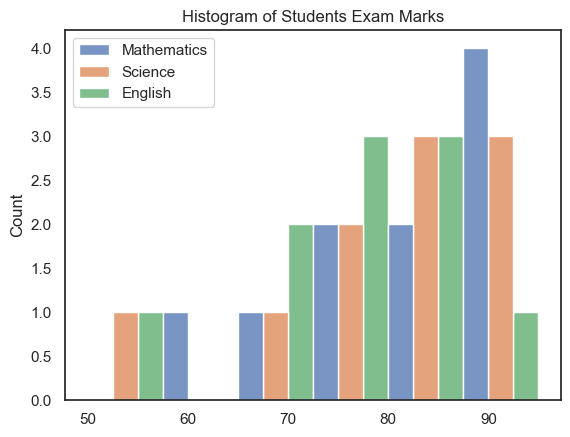

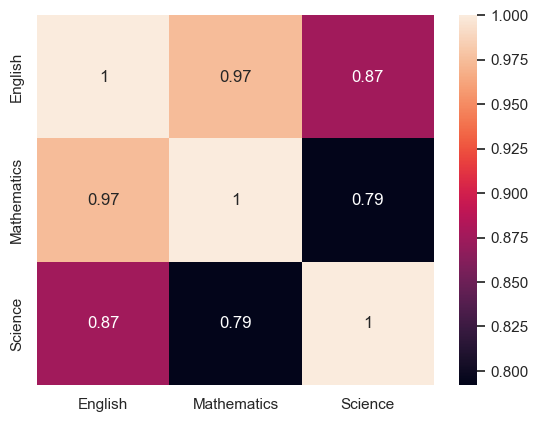

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='white', palette='deep')

data = {
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Mathematics': [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    'Science': [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    'English': [78, 74, 85, 80, 68, 90, 50, 77, 83, 72]
}

data = pd.DataFrame(data)

print('Descriptive Statistics')
print(data.describe())

sns.histplot(data, multiple='dodge')
plt.title('Histogram of Students Exam Marks')
plt.show()

correlation = data[['English', 'Mathematics', 'Science']].corr()
correlation

sns.heatmap(correlation, annot=True)
plt.show()


Question 4:

A pharmaceutical company conducted a clinical trial with two groups: one receiving medication and the other a placebo. How do you perform a hypothesis test to determine the effectiveness of the medication?

In [11]:
from scipy import stats
medication_group = [110, 115, 108, 102, 107, 99, 111, 104, 109, 101]
placebo_group = [120, 125, 130, 122, 128, 119, 124, 127, 123, 126]

tstat, p_value = stats.ttest_ind(medication_group, placebo_group)

print('T-Statistic:', tstat)
print('P-Value::', p_value)

# Null Hypothesis: There is no significant difference. The medication is not effective
# Alternative Hypothesis: There is a significant difference. The medication is effective

result = 'Reject the null hypothesis: The medication is effective' if p_value < 0.05 else 'Accept the null hypothesis: The medication is not effective.'
print(result)


T-Statistic: -9.201427649220966
P-Value:: 3.163912817600812e-08
Reject the null hypothesis: The medication is effective


Question 5 : 

A company conducted a customer satisfaction survey where customers rated their experience on a scale of 1 to 10. Analyze the survey results to calculate descriptive statistics and visualize the distribution of customer satisfaction ratings.

Mean Rating: 7.5
Median Rating: 7.5
Mode Rating: 7
Standard Deviation: 1.746424919657298


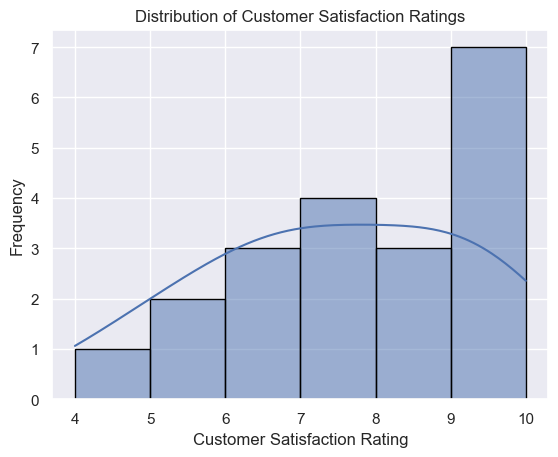

In [22]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook')

ratings = [8, 9, 7, 5, 6, 10, 9, 4, 7, 8, 
           6, 9, 10, 5, 8, 7, 6, 9, 10, 7]

mean_rating = np.mean(ratings)
median_rating = np.median(ratings)
mode_rating = stats.mode(ratings)
std_rating = np.std(ratings)

print('Mean Rating:', mean_rating)
print('Median Rating:', median_rating)
print('Mode Rating:', mode_rating[0])
print('Standard Deviation:', std_rating)

sns.histplot(ratings, kde=True, line_kws={'color':'blue'}, edgecolor='black')
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Satisfaction Ratings')
plt.show()
